# 03 Visual Storytelling: Churn Retention Intelligence

This notebook builds the portfolio-ready visualization layer for the churn project. It uses the existing processed dataset, model predictions, threshold comparisons, feature importance, and retention simulation outputs. The goal is to turn the technical workflow into a business-facing story suitable for a README, analytics report, or dashboard brief.

**Storyline**

1. Where churn concentrates in the customer base.
2. Whether the model ranks churn risk well enough for action.
3. Which operating setup creates the strongest retention economics.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "model_dataset.csv"
PREDICTIONS_PATH = PROJECT_ROOT / "outputs" / "predictions" / "model_comparison_predictions.csv"
MODEL_COMPARISON_PATH = PROJECT_ROOT / "outputs" / "metrics" / "model_comparison.csv"
THRESHOLD_PATH = PROJECT_ROOT / "outputs" / "metrics" / "threshold_comparison.csv"
TOPK_PATH = PROJECT_ROOT / "outputs" / "metrics" / "topk_comparison.csv"
FEATURE_IMPORTANCE_PATH = PROJECT_ROOT / "outputs" / "metrics" / "feature_importance.csv"
RETENTION_SIM_PATH = PROJECT_ROOT / "outputs" / "metrics" / "retention_simulation.csv"

EDA_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
MODELING_DIR = PROJECT_ROOT / "reports" / "figures" / "modeling"
BUSINESS_DIR = PROJECT_ROOT / "reports" / "figures" / "business"
for directory in [EDA_DIR, MODELING_DIR, BUSINESS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "font.family": "DejaVu Sans",
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.edgecolor": "#CBD5E1",
        "axes.labelcolor": "#334155",
        "xtick.color": "#475569",
        "ytick.color": "#475569",
        "grid.color": "#E2E8F0",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLORS = {
    "churn": "#E76F51",
    "retained": "#2A9D8F",
    "primary": "#264653",
    "secondary": "#E9C46A",
    "accent": "#457B9D",
    "muted": "#94A3B8",
    "light": "#F8FAFC",
    "text": "#1E293B",
}
MODEL_COLORS = {
    "GradientBoostingClassifier": COLORS["primary"],
    "LogisticRegression": COLORS["accent"],
    "RandomForestClassifier": COLORS["muted"],
}
SETUP_COLORS = {
    "Threshold 0.40": COLORS["primary"],
    "Top 10% targeting": COLORS["secondary"],
}


def pct(value: float) -> str:
    return f"{value:.1%}"


def money(value: float) -> str:
    return f"${value:,.0f}"


def clean_label(value: str) -> str:
    return str(value).replace("GradientBoostingClassifier", "Gradient Boosting").replace("LogisticRegression", "Logistic Regression").replace("RandomForestClassifier", "Random Forest")


def save_figure(fig: plt.Figure, path: Path) -> None:
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")


def soften_axis(ax):
    ax.grid(axis="x", alpha=0.55)
    ax.grid(axis="y", alpha=0.15)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#CBD5E1")


def label_barh(ax, values, fmt="percent", x_pad=0.01, suffix=""):
    max_value = max(values) if len(values) else 0
    for i, value in enumerate(values):
        if fmt == "percent":
            text = pct(value)
        elif fmt == "money":
            text = money(value)
        elif fmt == "count":
            text = f"{value:,.0f}{suffix}"
        else:
            text = f"{value:.2f}{suffix}"
        ax.text(value + max_value * x_pad, i, text, va="center", ha="left", fontsize=10, color=COLORS["text"])


def churn_summary(data: pd.DataFrame, column: str, order=None, sort_by_rate=True) -> pd.DataFrame:
    summary = (
        data.groupby(column, dropna=False)["churn_flag"]
        .agg(customers="count", churners="sum", churn_rate="mean")
        .reset_index()
    )
    if order is not None:
        summary[column] = pd.Categorical(summary[column], categories=order, ordered=True)
        summary = summary.sort_values(column)
        summary[column] = summary[column].astype(str)
    elif sort_by_rate:
        summary = summary.sort_values("churn_rate", ascending=False)
    return summary


In [2]:
df = pd.read_csv(DATA_PATH)
predictions = pd.read_csv(PREDICTIONS_PATH)
model_comparison = pd.read_csv(MODEL_COMPARISON_PATH)
thresholds = pd.read_csv(THRESHOLD_PATH)
topk = pd.read_csv(TOPK_PATH)
feature_importance = pd.read_csv(FEATURE_IMPORTANCE_PATH)
retention = pd.read_csv(RETENTION_SIM_PATH)

df["churn_flag"] = (df["churn"] == "Yes").astype(int)
overall_churn_rate = df["churn_flag"].mean()
churners = int(df["churn_flag"].sum())
non_churners = int((1 - df["churn_flag"]).sum())

summary_snapshot = pd.DataFrame(
    {
        "Metric": ["Customers", "Observed churners", "Overall churn rate", "Held-out test rows", "Held-out churners"],
        "Value": [
            f"{len(df):,}",
            f"{churners:,}",
            pct(overall_churn_rate),
            f"{model_comparison['test_rows'].iloc[0]:,}",
            f"{int(predictions[predictions['model'] == 'GradientBoostingClassifier']['actual_churn'].sum()):,}",
        ],
    }
)
summary_snapshot


,Metric,Value
0,Customers,"7,032"
1,Observed churners,"1,869"
2,Overall churn rate,26.6%
3,Held-out test rows,"1,407"
4,Held-out churners,374


## EDA Visuals: Find The Churn Concentration

These visuals frame churn as a business prioritization problem. The goal is not just to show which segments are different, but to identify where retention teams should focus attention first.


Saved reports\figures\eda\overall_churn_rate.png


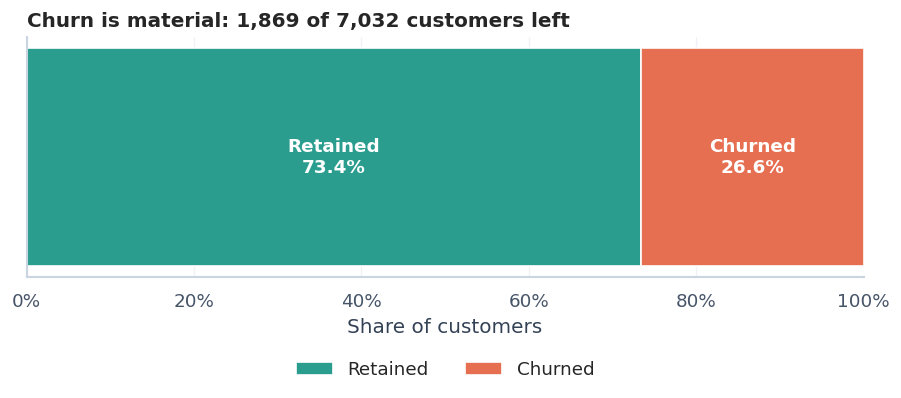

In [3]:
# Overall churn rate
fig, ax = plt.subplots(figsize=(9, 2.6))
retained_rate = 1 - overall_churn_rate
ax.barh([0], [retained_rate], color=COLORS["retained"], height=0.48, label="Retained")
ax.barh([0], [overall_churn_rate], left=[retained_rate], color=COLORS["churn"], height=0.48, label="Churned")
ax.text(retained_rate / 2, 0, f"Retained{chr(10)}{pct(retained_rate)}", va="center", ha="center", color="white", fontsize=11, fontweight="bold")
ax.text(retained_rate + overall_churn_rate / 2, 0, f"Churned{chr(10)}{pct(overall_churn_rate)}", va="center", ha="center", color="white", fontsize=11, fontweight="bold")
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Share of customers")
ax.set_title(f"Churn is material: {churners:,} of {len(df):,} customers left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=False)
soften_axis(ax)
save_figure(fig, EDA_DIR / "overall_churn_rate.png")
plt.show()


Saved reports\figures\eda\churn_rate_by_contract.png


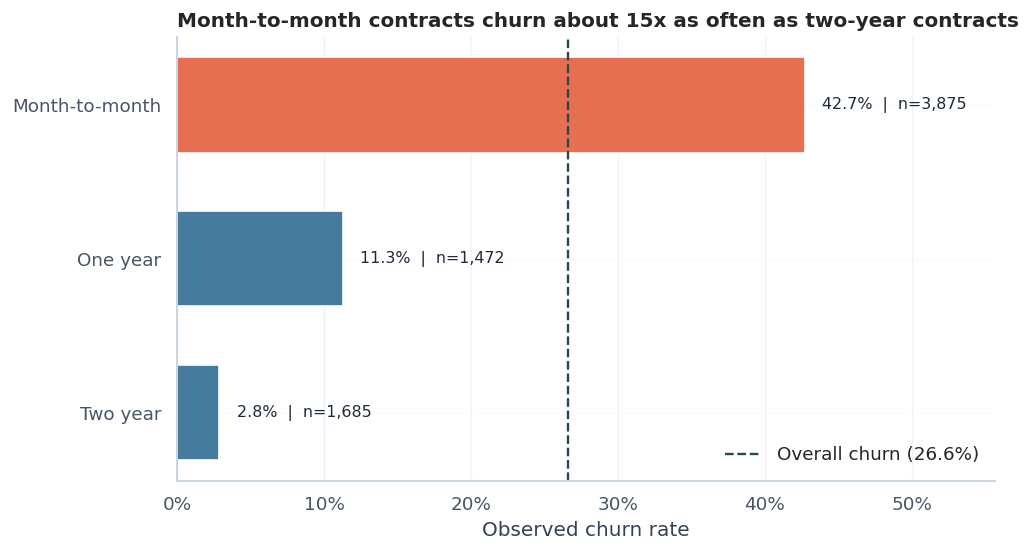

Saved reports\figures\eda\churn_rate_by_tenure_group.png


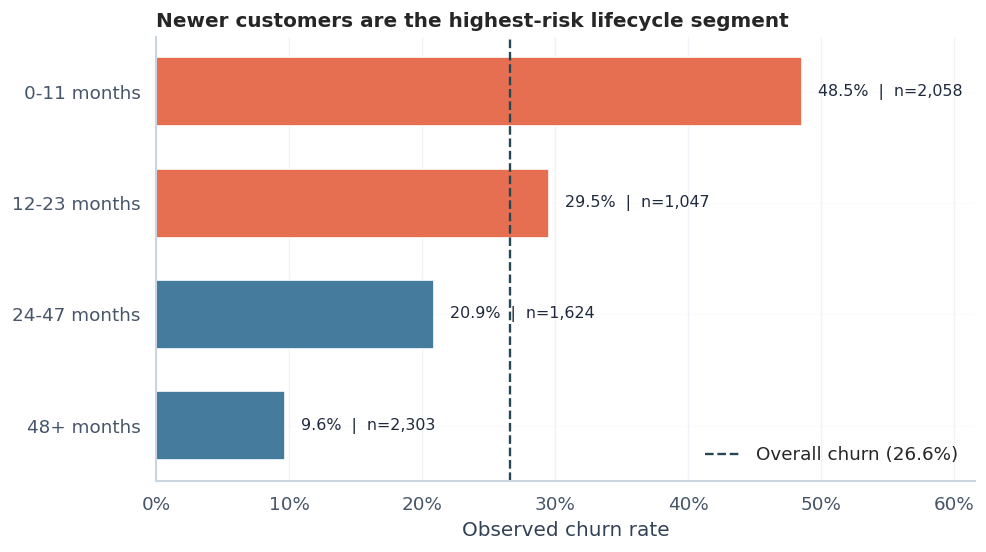

Saved reports\figures\eda\churn_rate_by_payment_method.png


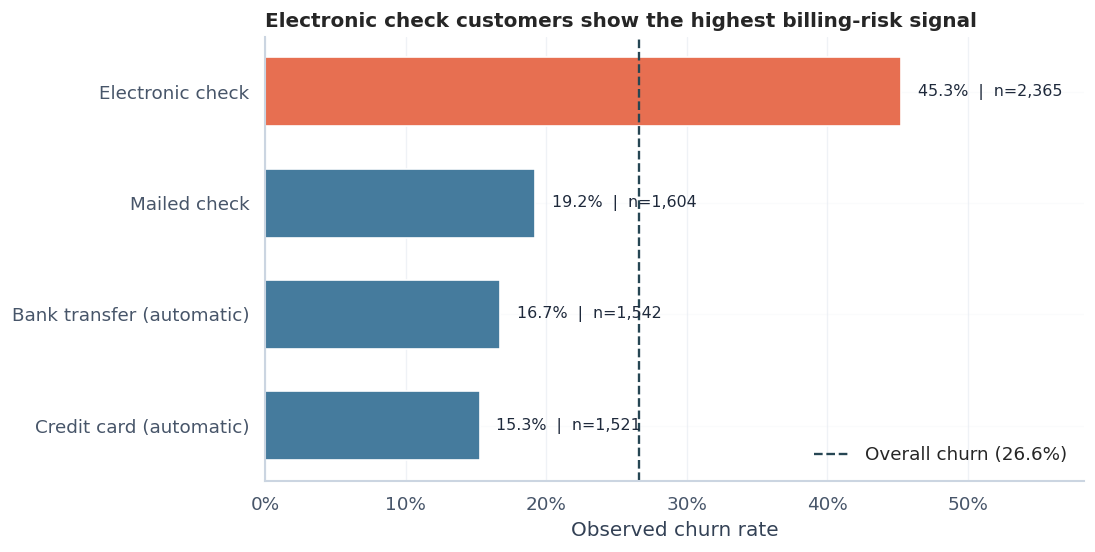

Saved reports\figures\eda\churn_rate_by_internet_service.png


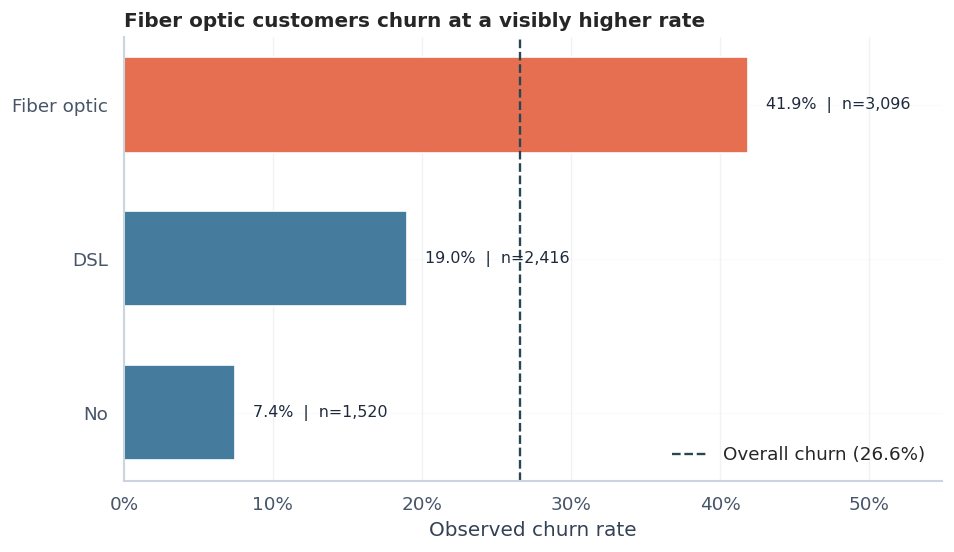

Saved reports\figures\eda\churn_rate_by_online_security.png


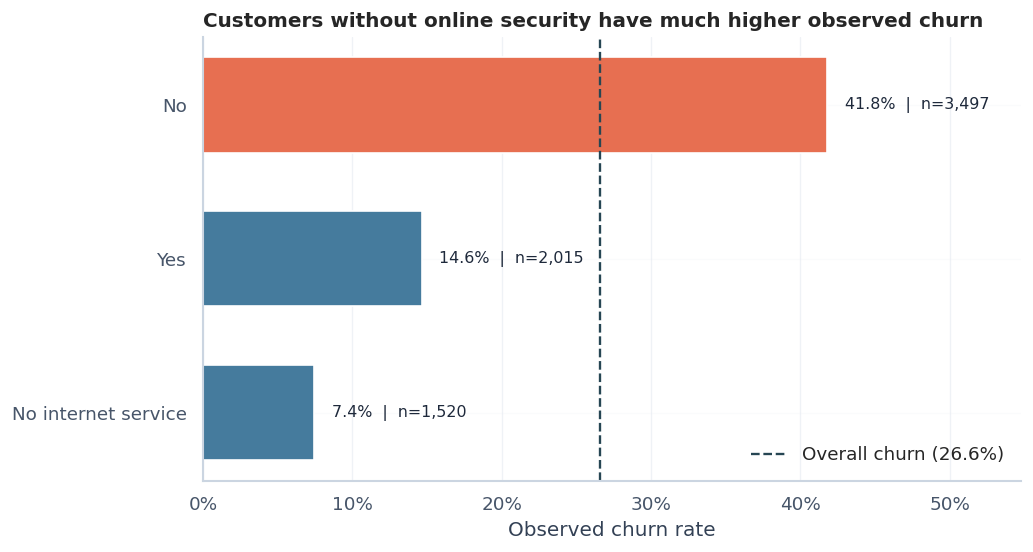

Saved reports\figures\eda\churn_rate_by_tech_support.png


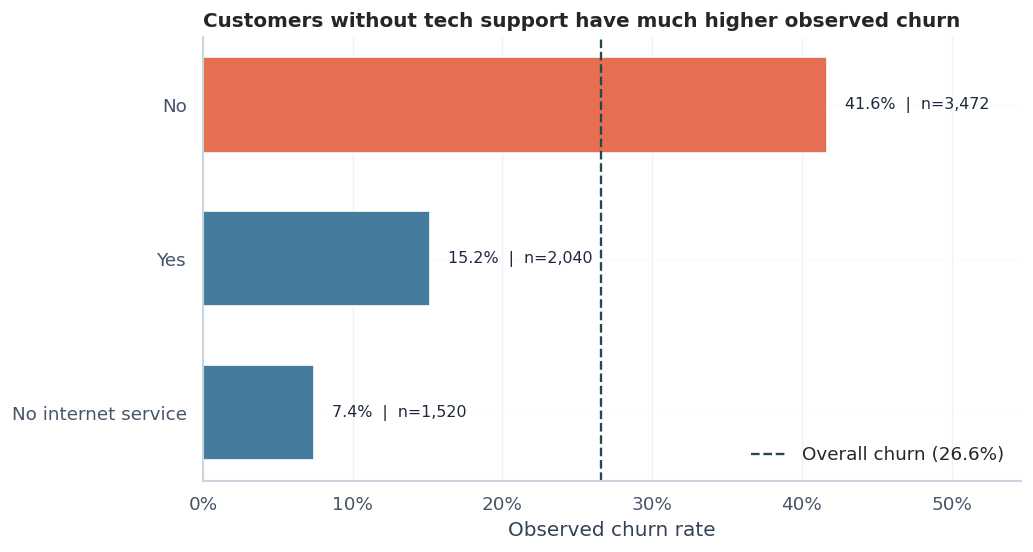

In [4]:
def plot_churn_rate_bar(column, title, filename, order=None, sort_by_rate=True, figsize=(8.8, 4.8)):
    summary = churn_summary(df, column, order=order, sort_by_rate=sort_by_rate)
    labels = summary[column].astype(str).tolist()
    values = summary["churn_rate"].to_numpy()
    counts = summary["customers"].to_numpy()
    colors = [COLORS["churn"] if value >= overall_churn_rate else COLORS["accent"] for value in values]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, values, color=colors, height=0.62)
    ax.axvline(overall_churn_rate, color=COLORS["primary"], linestyle="--", linewidth=1.4, label=f"Overall churn ({pct(overall_churn_rate)})")
    for y, (value, count) in enumerate(zip(values, counts)):
        ax.text(value + 0.012, y, f"{pct(value)}  |  n={count:,}", va="center", ha="left", fontsize=9.5, color=COLORS["text"])
    ax.set_xlim(0, max(values.max() + 0.13, overall_churn_rate + 0.15))
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("Observed churn rate")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    ax.invert_yaxis()
    soften_axis(ax)
    save_figure(fig, EDA_DIR / filename)
    plt.show()

contract_order = ["Month-to-month", "One year", "Two year"]
tenure_order = ["0-11 months", "12-23 months", "24-47 months", "48+ months"]

contract_summary = churn_summary(df, "contract", order=contract_order, sort_by_rate=False)
contract_ratio = contract_summary.loc[contract_summary["contract"] == "Month-to-month", "churn_rate"].iloc[0] / contract_summary.loc[contract_summary["contract"] == "Two year", "churn_rate"].iloc[0]
plot_churn_rate_bar(
    "contract",
    f"Month-to-month contracts churn about {contract_ratio:.0f}x as often as two-year contracts",
    "churn_rate_by_contract.png",
    order=contract_order,
    sort_by_rate=False,
)

plot_churn_rate_bar(
    "tenure_group",
    "Newer customers are the highest-risk lifecycle segment",
    "churn_rate_by_tenure_group.png",
    order=tenure_order,
    sort_by_rate=False,
)

plot_churn_rate_bar(
    "payment_method",
    "Electronic check customers show the highest billing-risk signal",
    "churn_rate_by_payment_method.png",
)

plot_churn_rate_bar(
    "internet_service",
    "Fiber optic customers churn at a visibly higher rate",
    "churn_rate_by_internet_service.png",
)

plot_churn_rate_bar(
    "online_security",
    "Customers without online security have much higher observed churn",
    "churn_rate_by_online_security.png",
)

plot_churn_rate_bar(
    "tech_support",
    "Customers without tech support have much higher observed churn",
    "churn_rate_by_tech_support.png",
)


Saved reports\figures\eda\monthly_charges_distribution_by_churn.png


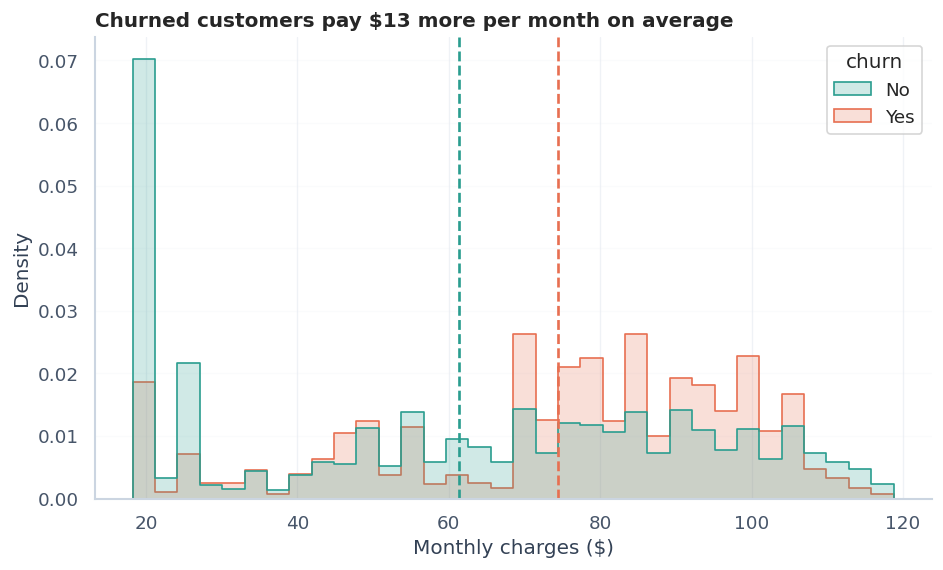

Saved reports\figures\eda\total_charges_distribution_by_churn.png


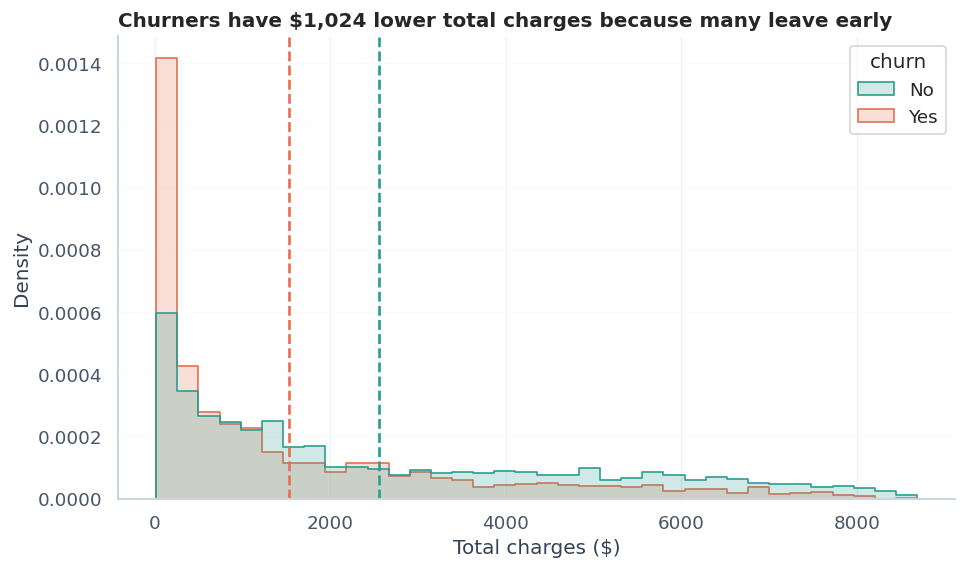

In [5]:
# Monthly charges distribution by churn
charge_means = df.groupby("churn")["monthly_charges"].mean()
monthly_gap = charge_means["Yes"] - charge_means["No"]
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x="monthly_charges",
    hue="churn",
    hue_order=["No", "Yes"],
    bins=34,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.22,
    palette={"No": COLORS["retained"], "Yes": COLORS["churn"]},
    ax=ax,
)
ax.axvline(charge_means["No"], color=COLORS["retained"], linestyle="--", linewidth=1.6)
ax.axvline(charge_means["Yes"], color=COLORS["churn"], linestyle="--", linewidth=1.6)
ax.set_xlabel("Monthly charges ($)")
ax.set_ylabel("Density")
ax.set_title(f"Churned customers pay ${monthly_gap:.0f} more per month on average")
soften_axis(ax)
save_figure(fig, EDA_DIR / "monthly_charges_distribution_by_churn.png")
plt.show()

# Total charges distribution by churn
total_means = df.groupby("churn")["total_charges"].mean()
total_gap = total_means["No"] - total_means["Yes"]
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x="total_charges",
    hue="churn",
    hue_order=["No", "Yes"],
    bins=36,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.22,
    palette={"No": COLORS["retained"], "Yes": COLORS["churn"]},
    ax=ax,
)
ax.axvline(total_means["No"], color=COLORS["retained"], linestyle="--", linewidth=1.6)
ax.axvline(total_means["Yes"], color=COLORS["churn"], linestyle="--", linewidth=1.6)
ax.set_xlabel("Total charges ($)")
ax.set_ylabel("Density")
ax.set_title(f"Churners have ${total_gap:,.0f} lower total charges because many leave early")
soften_axis(ax)
save_figure(fig, EDA_DIR / "total_charges_distribution_by_churn.png")
plt.show()


C:\Users\KHOA\AppData\Local\Temp\ipykernel_22212\3544677639.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = heatmap_df.pivot_table(index="contract", columns="tenure_group", values="churn_flag", aggfunc="mean")


Saved reports\figures\eda\churn_rate_heatmap_contract_tenure.png


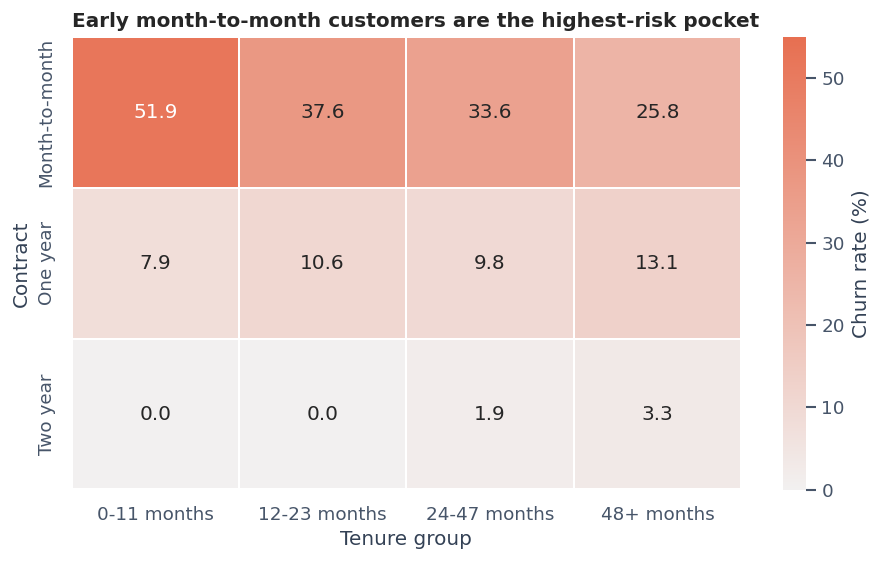

In [6]:
# Heatmap: contract by tenure group
heatmap_df = df.copy()
heatmap_df["contract"] = pd.Categorical(heatmap_df["contract"], categories=contract_order, ordered=True)
heatmap_df["tenure_group"] = pd.Categorical(heatmap_df["tenure_group"], categories=tenure_order, ordered=True)
pivot = heatmap_df.pivot_table(index="contract", columns="tenure_group", values="churn_flag", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 4.9))
cmap = sns.light_palette(COLORS["churn"], as_cmap=True)
sns.heatmap(
    pivot * 100,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    vmin=0,
    vmax=55,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Churn rate (%)"},
    ax=ax,
)
ax.set_xlabel("Tenure group")
ax.set_ylabel("Contract")
ax.set_title("Early month-to-month customers are the highest-risk pocket")
save_figure(fig, EDA_DIR / "churn_rate_heatmap_contract_tenure.png")
plt.show()


## Modeling Visuals: Convert Risk Scores Into Targeting Confidence

The modeling visuals show both ranking performance and campaign operating trade-offs. ROC and precision-recall curves answer whether the scores separate churners from non-churners; threshold and top-k charts translate those scores into action lists.


Saved reports\figures\modeling\roc_curve_model_comparison.png


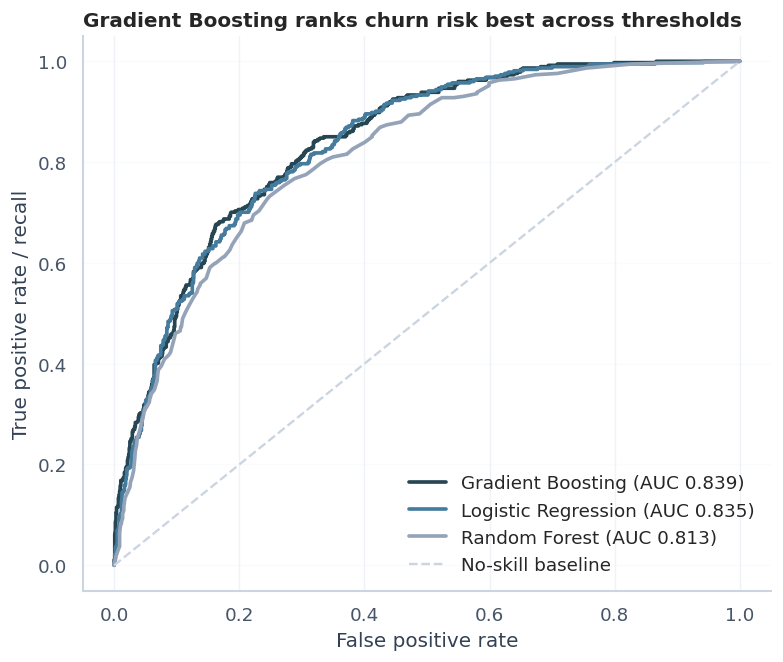

Saved reports\figures\modeling\precision_recall_curve_model_comparison.png


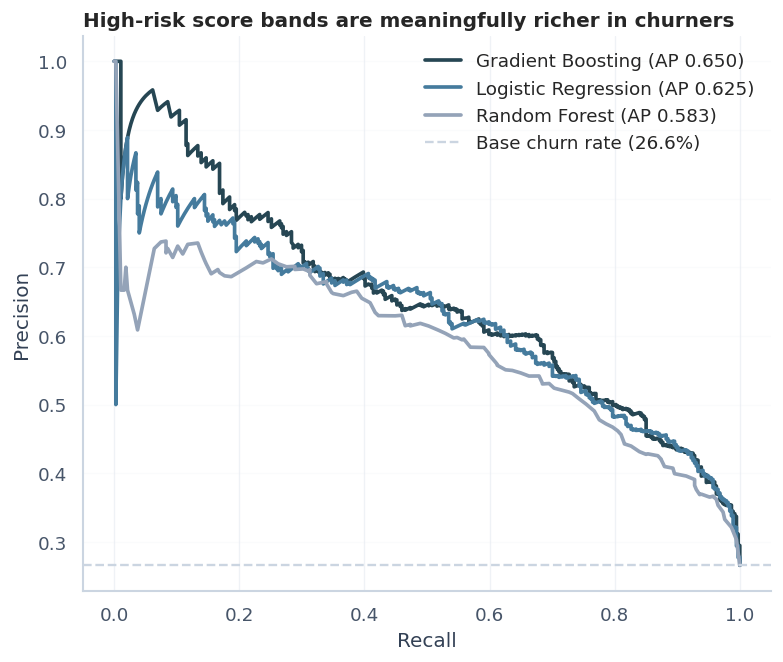

In [7]:
# ROC curve by model
fig, ax = plt.subplots(figsize=(7.4, 6))
for model_name, model_preds in predictions.groupby("model"):
    y_true = model_preds["actual_churn"]
    y_score = model_preds["churn_probability"]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, linewidth=2.2, color=MODEL_COLORS.get(model_name, COLORS["muted"]), label=f"{clean_label(model_name)} (AUC {auc:.3f})")
ax.plot([0, 1], [0, 1], color="#CBD5E1", linestyle="--", linewidth=1.4, label="No-skill baseline")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate / recall")
ax.set_title("Gradient Boosting ranks churn risk best across thresholds")
ax.legend(frameon=False, loc="lower right")
soften_axis(ax)
save_figure(fig, MODELING_DIR / "roc_curve_model_comparison.png")
plt.show()

# Precision-recall curve by model
fig, ax = plt.subplots(figsize=(7.4, 6))
base_rate = predictions[predictions["model"] == "GradientBoostingClassifier"]["actual_churn"].mean()
for model_name, model_preds in predictions.groupby("model"):
    y_true = model_preds["actual_churn"]
    y_score = model_preds["churn_probability"]
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    avg_precision = average_precision_score(y_true, y_score)
    ax.plot(recall, precision, linewidth=2.2, color=MODEL_COLORS.get(model_name, COLORS["muted"]), label=f"{clean_label(model_name)} (AP {avg_precision:.3f})")
ax.axhline(base_rate, color="#CBD5E1", linestyle="--", linewidth=1.4, label=f"Base churn rate ({pct(base_rate)})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("High-risk score bands are meaningfully richer in churners")
ax.legend(frameon=False, loc="upper right")
soften_axis(ax)
save_figure(fig, MODELING_DIR / "precision_recall_curve_model_comparison.png")
plt.show()


Saved reports\figures\modeling\confusion_matrix_gb_threshold_040.png


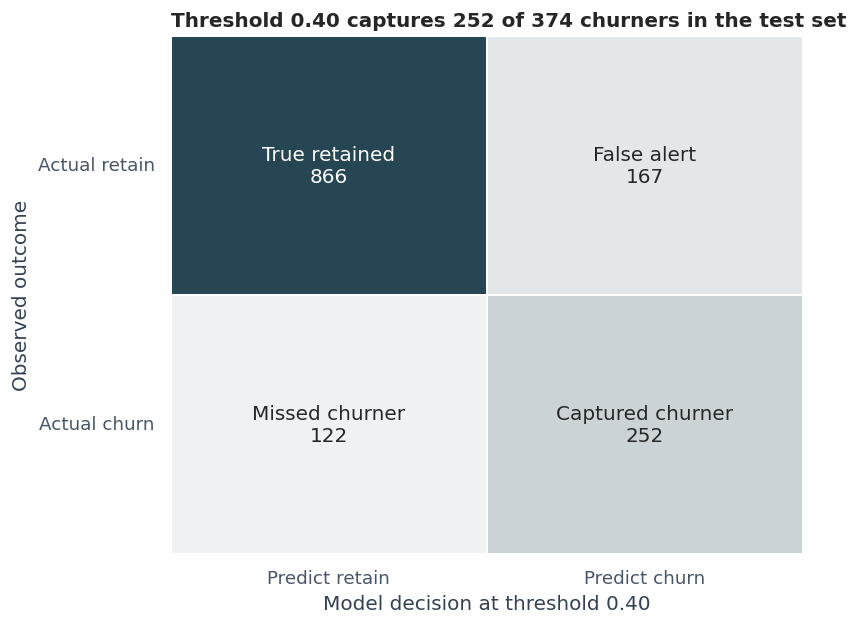

In [8]:
# Confusion matrix at the recommended Gradient Boosting threshold
model_name = "GradientBoostingClassifier"
recommended_threshold = 0.40
gb_preds = predictions[predictions["model"] == model_name].copy()
gb_preds["predicted_at_040"] = (gb_preds["churn_probability"] >= recommended_threshold).astype(int)
cm = confusion_matrix(gb_preds["actual_churn"], gb_preds["predicted_at_040"], labels=[0, 1])
cm_labels = np.array([["True retained", "False alert"], ["Missed churner", "Captured churner"]])
annotations = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f"{cm_labels[i, j]}{chr(10)}{cm[i, j]:,}"

fig, ax = plt.subplots(figsize=(6.8, 5.6))
sns.heatmap(
    cm,
    annot=annotations,
    fmt="",
    cmap=sns.light_palette(COLORS["primary"], as_cmap=True),
    linewidths=1,
    linecolor="white",
    cbar=False,
    ax=ax,
)
ax.set_xticklabels(["Predict retain", "Predict churn"])
ax.set_yticklabels(["Actual retain", "Actual churn"], rotation=0)
ax.set_xlabel("Model decision at threshold 0.40")
ax.set_ylabel("Observed outcome")
ax.set_title("Threshold 0.40 captures 252 of 374 churners in the test set")
save_figure(fig, MODELING_DIR / "confusion_matrix_gb_threshold_040.png")
plt.show()


Saved reports\figures\modeling\threshold_comparison_gb.png


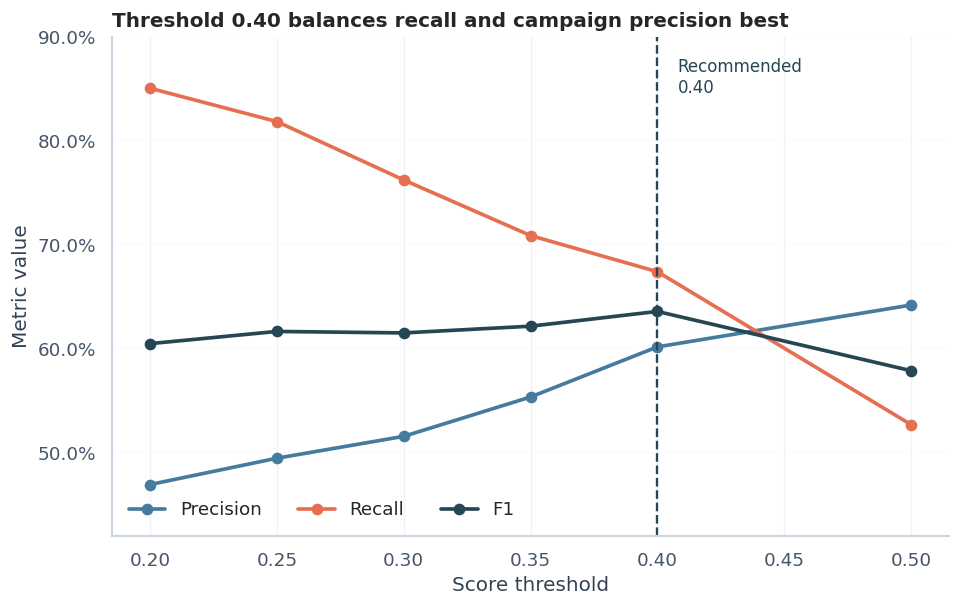

Saved reports\figures\modeling\topk_capture_comparison.png


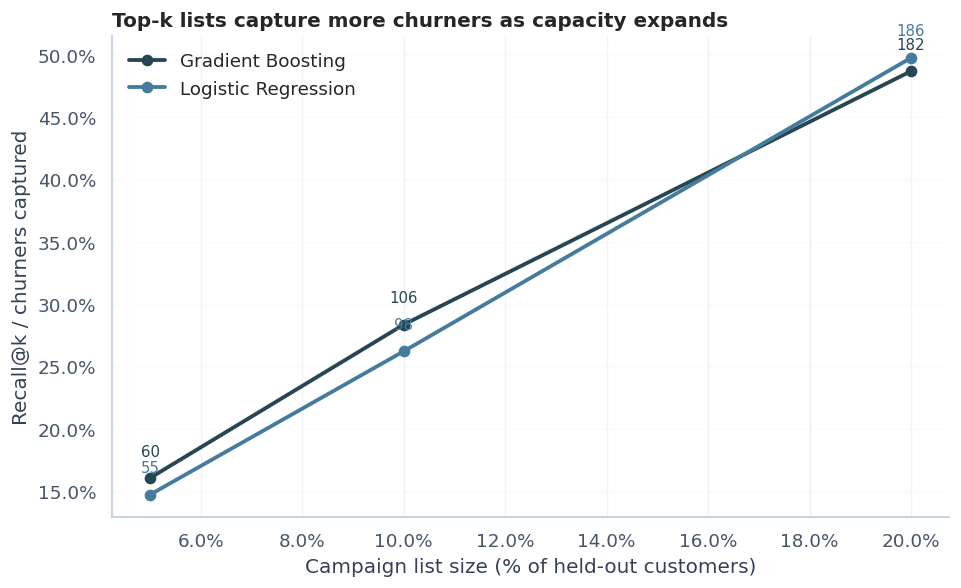

In [9]:
# Threshold comparison for Gradient Boosting
gb_thresholds = thresholds[thresholds["model"] == model_name].sort_values("threshold")
fig, ax1 = plt.subplots(figsize=(9, 5.4))
ax1.plot(gb_thresholds["threshold"], gb_thresholds["precision"], marker="o", color=COLORS["accent"], linewidth=2.2, label="Precision")
ax1.plot(gb_thresholds["threshold"], gb_thresholds["recall"], marker="o", color=COLORS["churn"], linewidth=2.2, label="Recall")
ax1.plot(gb_thresholds["threshold"], gb_thresholds["f1"], marker="o", color=COLORS["primary"], linewidth=2.2, label="F1")
ax1.axvline(recommended_threshold, color=COLORS["primary"], linestyle="--", linewidth=1.4)
ax1.text(recommended_threshold + 0.008, 0.88, "Recommended" + chr(10) + "0.40", color=COLORS["primary"], fontsize=10, va="top")
ax1.set_ylim(0.42, 0.90)
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.set_xlabel("Score threshold")
ax1.set_ylabel("Metric value")
ax1.set_title("Threshold 0.40 balances recall and campaign precision best")
ax1.legend(frameon=False, loc="lower left", ncol=3)
soften_axis(ax1)
save_figure(fig, MODELING_DIR / "threshold_comparison_gb.png")
plt.show()

# Top-k capture comparison
fig, ax = plt.subplots(figsize=(9, 5.2))
for model, model_topk in topk.groupby("model"):
    model_topk = model_topk.sort_values("top_k")
    ax.plot(model_topk["top_k"], model_topk["recall_at_k"], marker="o", linewidth=2.3, color=MODEL_COLORS.get(model, COLORS["muted"]), label=clean_label(model))
    for _, row in model_topk.iterrows():
        ax.text(row["top_k"], row["recall_at_k"] + 0.018, f"{int(row['churners_captured'])}", ha="center", fontsize=9, color=MODEL_COLORS.get(model, COLORS["text"]))
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Campaign list size (% of held-out customers)")
ax.set_ylabel("Recall@k / churners captured")
ax.set_title("Top-k lists capture more churners as capacity expands")
ax.legend(frameon=False, loc="upper left")
soften_axis(ax)
save_figure(fig, MODELING_DIR / "topk_capture_comparison.png")
plt.show()


Saved reports\figures\modeling\feature_importance_top10.png


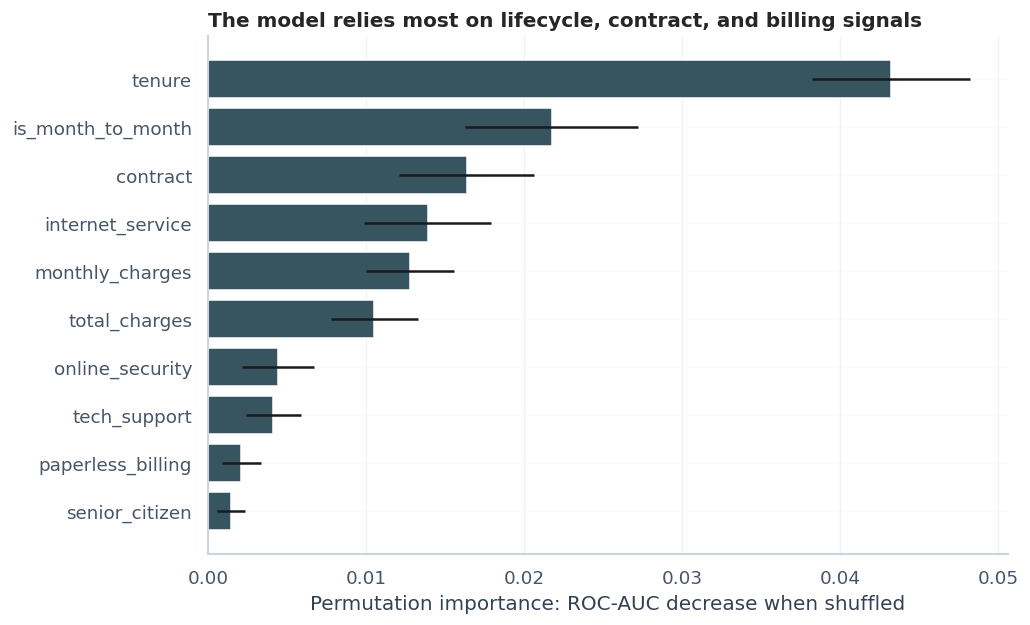

In [10]:
# Feature importance
importance_top = feature_importance.sort_values("importance_mean", ascending=False).head(10).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(8.6, 5.6))
ax.barh(importance_top["feature"], importance_top["importance_mean"], xerr=importance_top["importance_std"], color=COLORS["primary"], alpha=0.92)
ax.set_xlabel("Permutation importance: ROC-AUC decrease when shuffled")
ax.set_ylabel("")
ax.set_title("The model relies most on lifecycle, contract, and billing signals")
soften_axis(ax)
save_figure(fig, MODELING_DIR / "feature_importance_top10.png")
plt.show()


## Business Visuals: Choose The Operating Setup

The business layer translates model quality into campaign decisions. The current simulation uses the existing assumptions from `reports/business_recommendation.md`: $5 outreach cost per customer, 15% save success rate among observed churners contacted, and $200 retained value per recovered customer.


Saved reports\figures\business\operating_setup_comparison.png


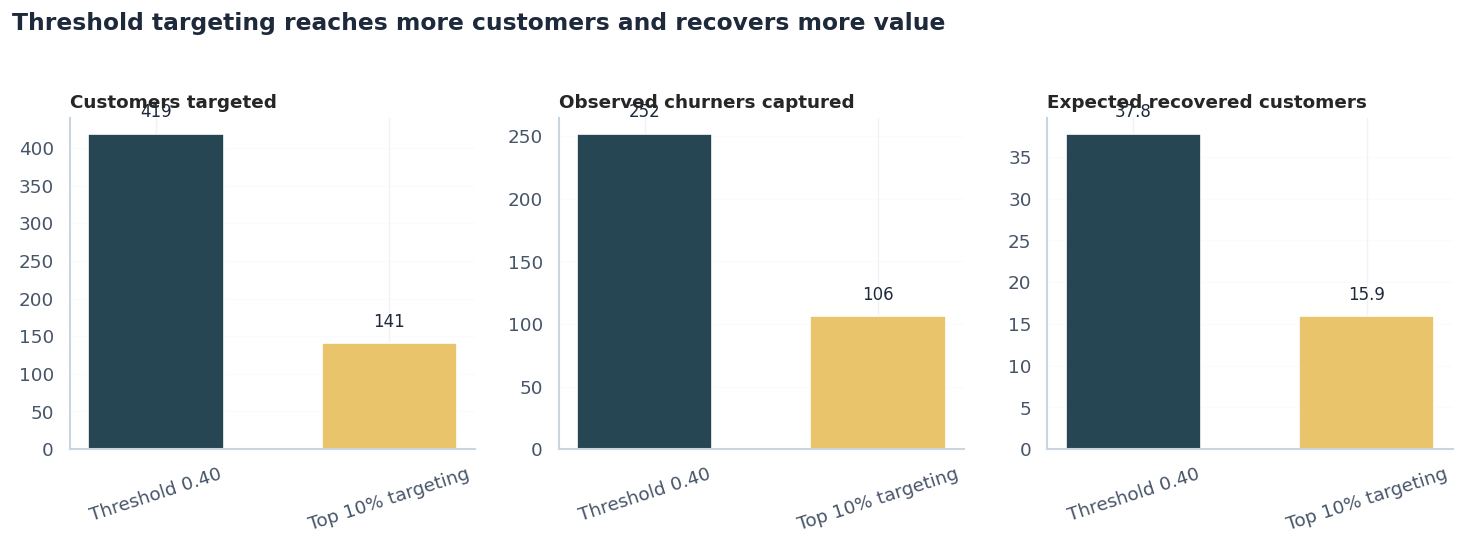

In [11]:
retention = retention.copy()
retention["scenario"] = pd.Categorical(retention["scenario"], categories=["Threshold 0.40", "Top 10% targeting"], ordered=True)
retention = retention.sort_values("scenario")

# Operating setup comparison across core business quantities
setup_metrics = retention.melt(
    id_vars="scenario",
    value_vars=["selected_customers", "observed_churners_captured", "expected_recovered_customers"],
    var_name="metric",
    value_name="value",
)
metric_labels = {
    "selected_customers": "Customers targeted",
    "observed_churners_captured": "Observed churners captured",
    "expected_recovered_customers": "Expected recovered customers",
}
setup_metrics["metric_label"] = setup_metrics["metric"].map(metric_labels)

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.4), sharey=False)
for ax, metric in zip(axes, ["selected_customers", "observed_churners_captured", "expected_recovered_customers"]):
    subset = setup_metrics[setup_metrics["metric"] == metric]
    colors = [SETUP_COLORS[str(s)] for s in subset["scenario"]]
    ax.bar(subset["scenario"].astype(str), subset["value"], color=colors, width=0.58)
    for x, value in enumerate(subset["value"]):
        label = f"{value:,.1f}" if metric == "expected_recovered_customers" else f"{value:,.0f}"
        ax.text(x, value + subset["value"].max() * 0.04, label, ha="center", va="bottom", fontsize=10, color=COLORS["text"])
    ax.set_title(metric_labels[metric], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=18)
    soften_axis(ax)
fig.suptitle("Threshold targeting reaches more customers and recovers more value", x=0.01, ha="left", y=1.03, fontsize=14, fontweight="bold", color=COLORS["text"])
fig.tight_layout()
save_figure(fig, BUSINESS_DIR / "operating_setup_comparison.png")
plt.show()


Saved reports\figures\business\expected_net_value_by_setup.png


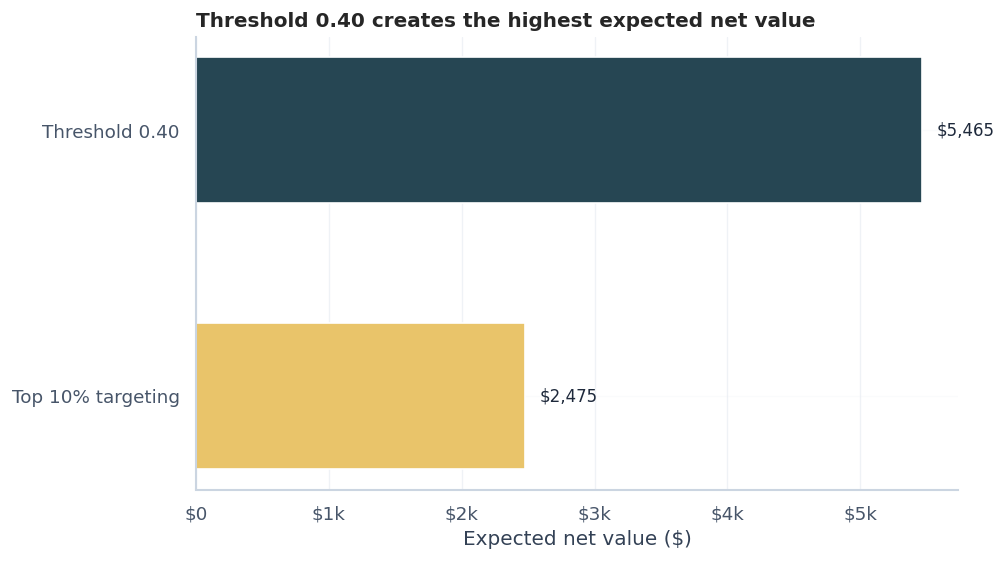

Saved reports\figures\business\customers_targeted_vs_churners_captured.png


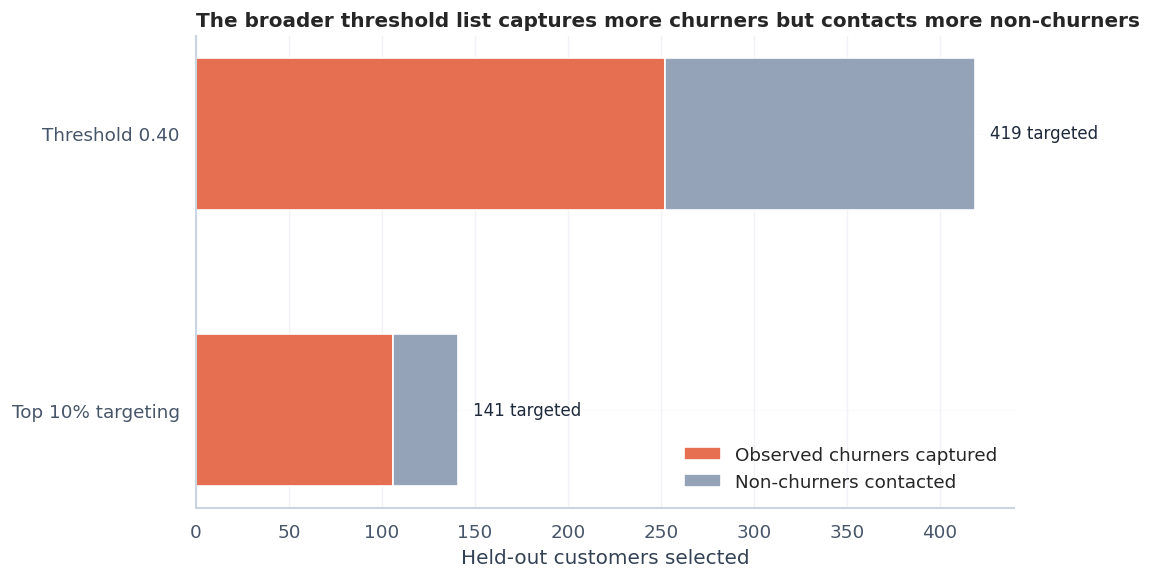

In [12]:
# Expected net value by setup
fig, ax = plt.subplots(figsize=(8.2, 4.9))
colors = [SETUP_COLORS[str(s)] for s in retention["scenario"]]
ax.barh(retention["scenario"].astype(str), retention["expected_net_value"], color=colors, height=0.55)
label_barh(ax, retention["expected_net_value"].to_numpy(), fmt="money", x_pad=0.02)
ax.set_xlabel("Expected net value ($)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000:.0f}k" if x else "$0"))
ax.set_ylabel("")
ax.set_title("Threshold 0.40 creates the highest expected net value")
ax.invert_yaxis()
soften_axis(ax)
save_figure(fig, BUSINESS_DIR / "expected_net_value_by_setup.png")
plt.show()

# Targeted customers split into captured churners and non-churners contacted
business_split = retention.copy()
business_split["non_churners_contacted"] = business_split["selected_customers"] - business_split["observed_churners_captured"]
fig, ax = plt.subplots(figsize=(8.8, 5.1))
y = np.arange(len(business_split))
ax.barh(y, business_split["observed_churners_captured"], color=COLORS["churn"], height=0.55, label="Observed churners captured")
ax.barh(y, business_split["non_churners_contacted"], left=business_split["observed_churners_captured"], color=COLORS["muted"], height=0.55, label="Non-churners contacted")
for i, row in business_split.iterrows():
    ax.text(row["selected_customers"] + 8, y[i], f"{int(row['selected_customers']):,} targeted", va="center", ha="left", fontsize=10, color=COLORS["text"])
ax.set_yticks(y)
ax.set_yticklabels(business_split["scenario"].astype(str))
ax.set_xlabel("Held-out customers selected")
ax.set_ylabel("")
ax.set_title("The broader threshold list captures more churners but contacts more non-churners")
ax.legend(frameon=False, loc="lower right")
ax.invert_yaxis()
soften_axis(ax)
save_figure(fig, BUSINESS_DIR / "customers_targeted_vs_churners_captured.png")
plt.show()


Saved reports\figures\business\precision_recall_topk_summary.png


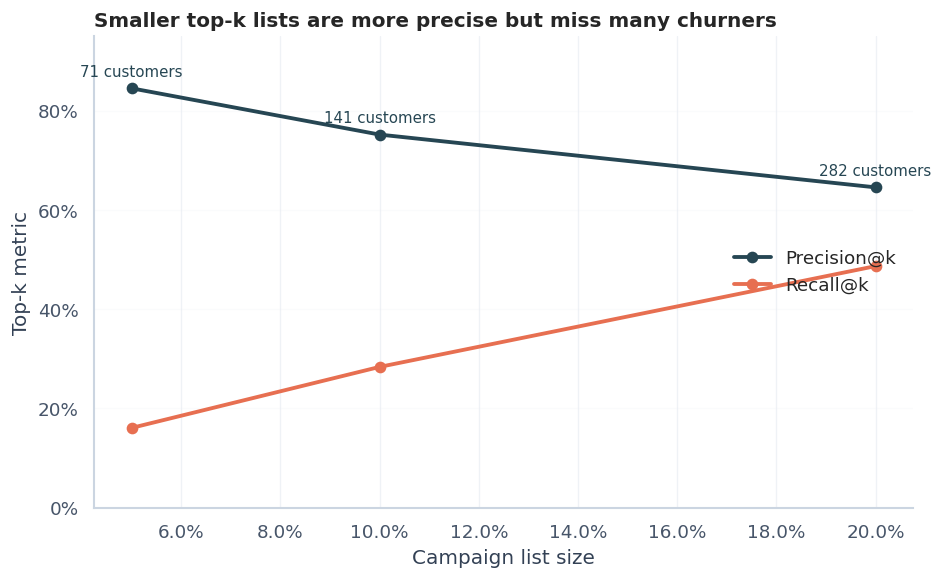

Saved reports\figures\business\scenario_economics_comparison.png


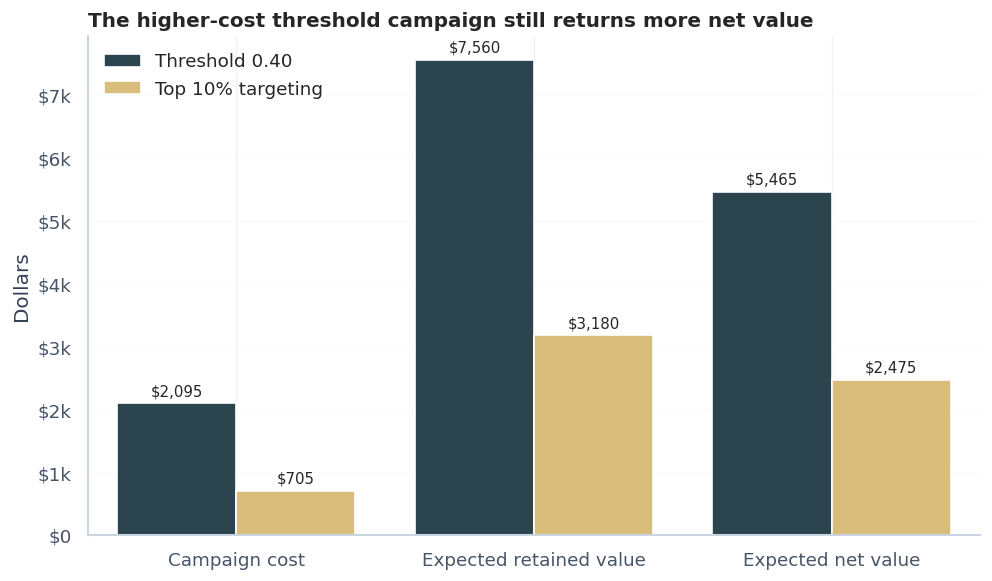

In [13]:
# Precision@k and recall@k summary for Gradient Boosting
business_topk = topk[topk["model"] == model_name].sort_values("top_k")
fig, ax = plt.subplots(figsize=(8.8, 5.1))
ax.plot(business_topk["top_k"], business_topk["precision_at_k"], marker="o", linewidth=2.3, color=COLORS["primary"], label="Precision@k")
ax.plot(business_topk["top_k"], business_topk["recall_at_k"], marker="o", linewidth=2.3, color=COLORS["churn"], label="Recall@k")
for _, row in business_topk.iterrows():
    ax.text(row["top_k"], row["precision_at_k"] + 0.025, f"{int(row['selected_count'])} customers", ha="center", fontsize=9, color=COLORS["primary"])
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 0.95)
ax.set_xlabel("Campaign list size")
ax.set_ylabel("Top-k metric")
ax.set_title("Smaller top-k lists are more precise but miss many churners")
ax.legend(frameon=False, loc="center right")
soften_axis(ax)
save_figure(fig, BUSINESS_DIR / "precision_recall_topk_summary.png")
plt.show()

# Scenario economics comparison
scenario_econ = retention.melt(
    id_vars="scenario",
    value_vars=["campaign_cost", "expected_retained_value", "expected_net_value"],
    var_name="metric",
    value_name="value",
)
scenario_econ["metric_label"] = scenario_econ["metric"].map(
    {
        "campaign_cost": "Campaign cost",
        "expected_retained_value": "Expected retained value",
        "expected_net_value": "Expected net value",
    }
)
fig, ax = plt.subplots(figsize=(9.6, 5.4))
sns.barplot(
    data=scenario_econ,
    x="metric_label",
    y="value",
    hue="scenario",
    palette=SETUP_COLORS,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, labels=[money(v.get_height()) for v in container], padding=3, fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("Dollars")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000:.0f}k" if x else "$0"))
ax.set_title("The higher-cost threshold campaign still returns more net value")
ax.legend(title="", frameon=False, loc="upper left")
soften_axis(ax)
save_figure(fig, BUSINESS_DIR / "scenario_economics_comparison.png")
plt.show()


In [14]:
created_figures = sorted(
    [p.relative_to(PROJECT_ROOT).as_posix() for p in EDA_DIR.glob("*.png")]
    + [p.relative_to(PROJECT_ROOT).as_posix() for p in MODELING_DIR.glob("*.png")]
    + [p.relative_to(PROJECT_ROOT).as_posix() for p in BUSINESS_DIR.glob("*.png")]
)
print(f"Created {len(created_figures)} visual storytelling figures:")
for figure in created_figures:
    print(f"- {figure}")


Created 21 visual storytelling figures:
- reports/figures/business/customers_targeted_vs_churners_captured.png
- reports/figures/business/expected_net_value_by_setup.png
- reports/figures/business/operating_setup_comparison.png
- reports/figures/business/precision_recall_topk_summary.png
- reports/figures/business/scenario_economics_comparison.png
- reports/figures/eda/churn_rate_by_contract.png
- reports/figures/eda/churn_rate_by_internet_service.png
- reports/figures/eda/churn_rate_by_online_security.png
- reports/figures/eda/churn_rate_by_payment_method.png
- reports/figures/eda/churn_rate_by_tech_support.png
- reports/figures/eda/churn_rate_by_tenure_group.png
- reports/figures/eda/churn_rate_heatmap_contract_tenure.png
- reports/figures/eda/monthly_charges_distribution_by_churn.png
- reports/figures/eda/overall_churn_rate.png
- reports/figures/eda/total_charges_distribution_by_churn.png
- reports/figures/modeling/confusion_matrix_gb_threshold_040.png
- reports/figures/modeling/fea